In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [17]:
df = pd.read_parquet("../data/flights_sample_2022.parquet")
df.shape

df.head()
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 61 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   FlightDate                               100000 non-null  datetime64[ns]
 1   Airline                                  100000 non-null  object        
 2   Origin                                   100000 non-null  object        
 3   Dest                                     100000 non-null  object        
 4   Cancelled                                100000 non-null  bool          
 5   Diverted                                 100000 non-null  bool          
 6   CRSDepTime                               100000 non-null  int64         
 7   DepTime                                  97092 non-null   float64       
 8   DepDelayMinutes                          97092 non-null   float64       
 9   DepDelay                   

,FlightDate,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,...,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,DistanceGroup,DivAirportLandings
count,100000,100000.000000,97092.00000,97092.000000,97092.000000,96987.000000,96759.000000,96759.000000,100000.00000,96759.000000,...,97025.000000,97025.000000,96987.000000,96987.000000,100000.000000,96759.000000,96759.000000,96759.000000,100000.000000,100000.000000
mean,2022-04-18 14:10:54.624000256,1328.719910,1333.61381,16.178635,13.258662,1457.158898,15.968282,111.099154,141.44746,135.968892,...,16.979593,1355.173821,1454.180581,7.902276,1486.492700,7.697237,0.216073,-0.053432,3.665410,0.003800
min,2022-01-01 00:00:00,1.000000,1.00000,0.000000,-55.000000,1.000000,0.000000,9.000000,5.00000,16.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-86.000000,0.000000,-2.000000,1.000000,0.000000
25%,2022-02-25 00:00:00,913.000000,916.00000,0.000000,-5.000000,1046.000000,0.000000,60.000000,89.00000,83.000000,...,11.000000,931.000000,1043.000000,4.000000,1103.000000,-14.000000,0.000000,-1.000000,2.000000,0.000000
50%,2022-04-19 00:00:00,1320.000000,1324.00000,0.000000,-1.000000,1459.000000,0.000000,94.000000,125.00000,119.000000,...,15.000000,1337.000000,1456.000000,6.000000,1513.000000,-5.000000,0.000000,-1.000000,3.000000,0.000000
75%,2022-06-11 00:00:00,1735.000000,1744.00000,11.000000,11.000000,1914.000000,10.000000,141.000000,172.00000,167.000000,...,19.000000,1758.000000,1909.000000,9.000000,1920.000000,10.000000,0.000000,0.000000,5.000000,0.000000
max,2022-07-31 00:00:00,2359.000000,2400.00000,1677.000000,1677.000000,2400.000000,1666.000000,667.000000,690.00000,690.000000,...,175.000000,2400.000000,2400.000000,251.000000,2359.000000,1666.000000,1.000000,12.000000,11.000000,9.000000
std,NaN,491.085319,506.13566,52.412291,53.423751,543.531909,52.156268,70.053862,71.91191,72.006964,...,9.445704,508.239335,538.359867,6.730599,518.289396,55.443698,0.411567,2.503599,2.322747,0.117922


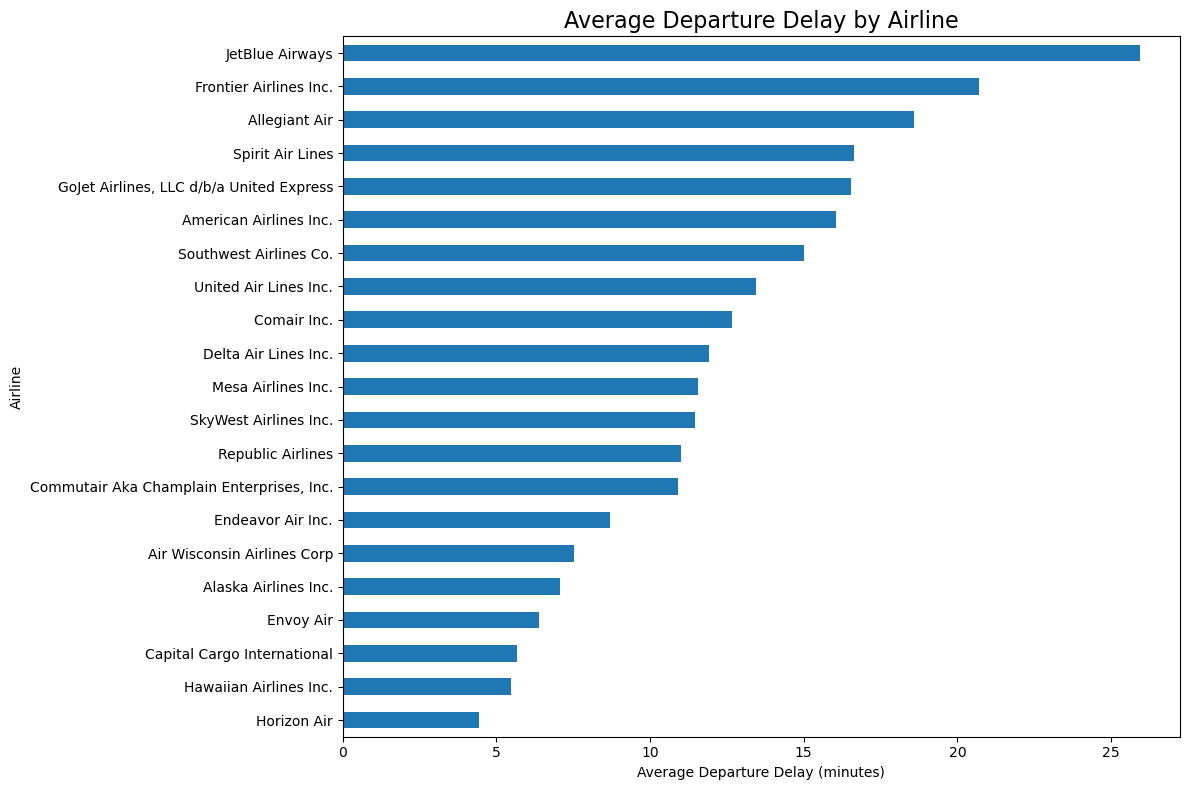

In [22]:
airline_delays = (
    df.groupby("Airline")["DepDelay"]
    .mean()
    .sort_values(ascending=False)
)
airline_delays

plt.figure(figsize=(12,8))
airline_delays.sort_values().plot(kind="barh")
plt.title("Average Departure Delay by Airline", fontsize=16)
plt.xlabel("Average Departure Delay (minutes)")
plt.ylabel("Airline")
plt.tight_layout()
plt.savefig("../visuals/airline_delay_bar_chart.png")
plt.show()

### Insights

JetBlue and Frontier showed the highest average departure delays in the dataset, while Horizon Air and Hawaiian airlines had the lowest average delays. This suggests substantial operational differences between carriers, potentially do to routes, airport congestion, scheduling, or weather patterns.

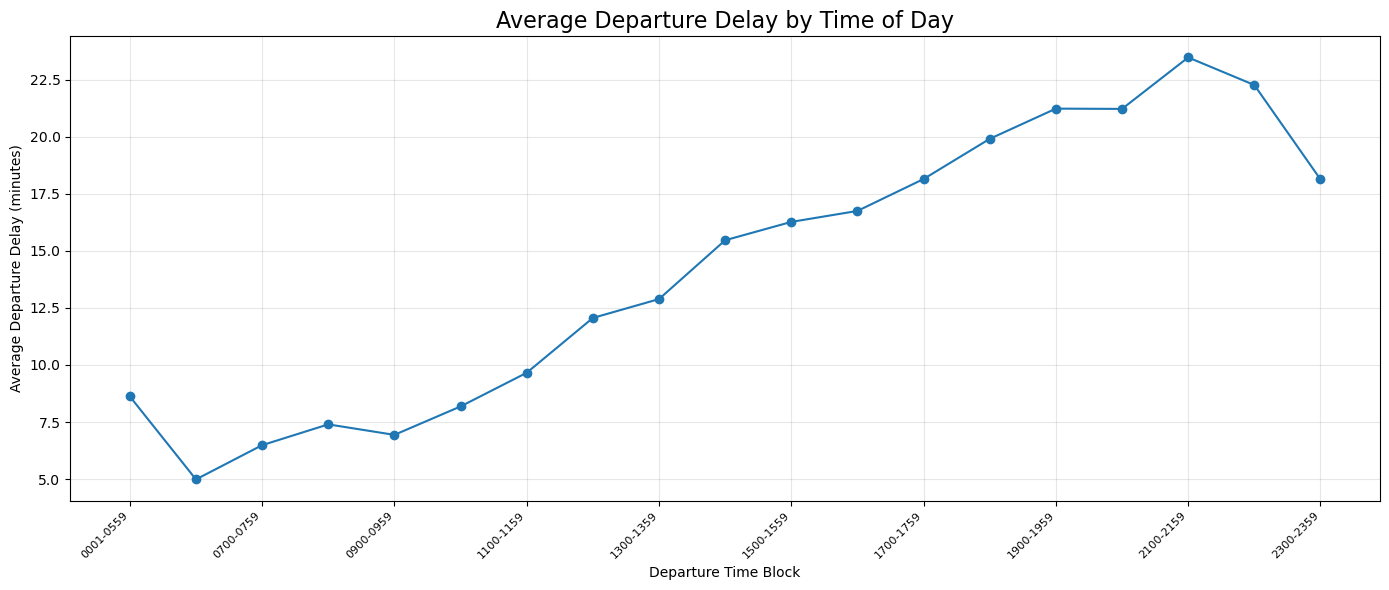

In [ ]:
time_delays = (
    df.groupby("DepTimeBlk")["DepDelay"]
    .mean()
    .sort_index()
)
time_delays

plt.figure(figsize=(14,6))
time_delays.plot(kind="line", marker="o")
plt.title("Average Departure Delay by Time of Day", fontsize=16)
plt.xlabel("Departure Time Block")
plt.ylabel("Average Departure Delay (minutes)")
plt.xticks(ticks=range(0, len(time_delays), 2),
           labels=time_delays.index[::2],
           rotation=45,
           ha="right",
           fontsize=8
           )
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/time_delay_line_chart.png")
plt.show()

## Insights

As the day goes on, it appears the average departure delay gets increasingly larger. This is most likely due to the snowball effect of one flight being delayed in beginning of the day, leading to further delays later on as everything gets pushed back in the timeline. It also evident that when there are less flights, such as throughout the night and early hours of the morning, the average delay time is smaller. 
NOTE: 0001-0559 flights were grouped into the same timeblock as there was less flight data due to there being less flights during those times. 

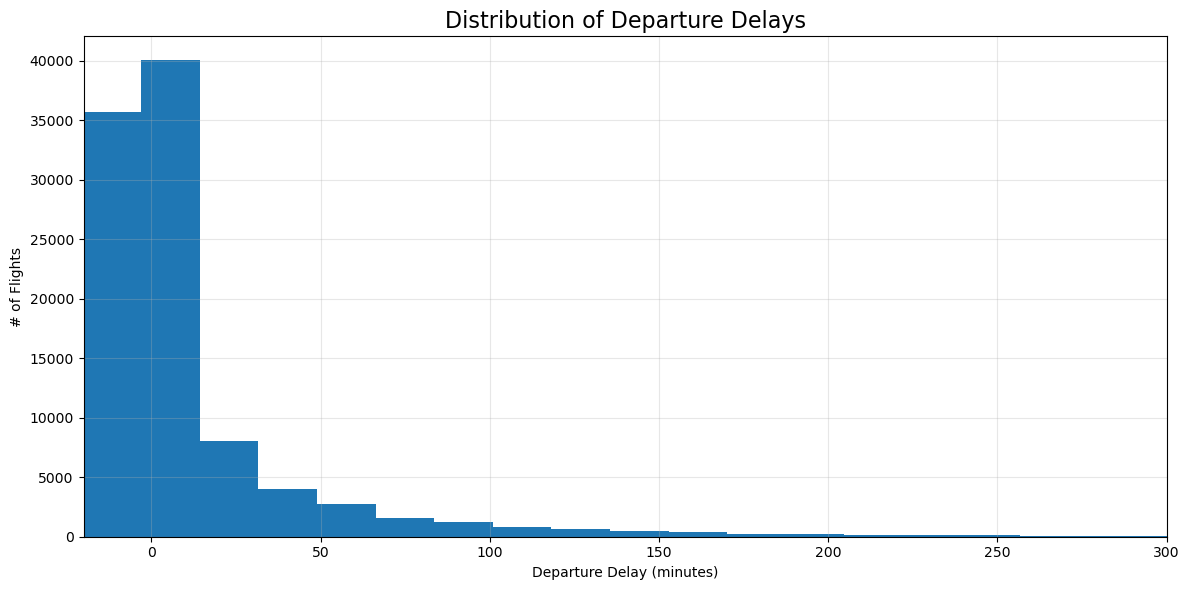

In [26]:
plt.figure(figsize=(12,6))
plt.hist(df["DepDelay"], bins=100)
plt.title("Distribution of Departure Delays", fontsize=16)
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("# of Flights")
plt.xlim(-20, 300)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/departure_delay_histogram.png")
plt.show()

## Insights

Most flights depart near their scheduled departure time with a strong concentration around minimal delays. The distribution does contain a long right tail, indicating that severe delays are less common, but they still do occur and substantially impact average delay metrics.

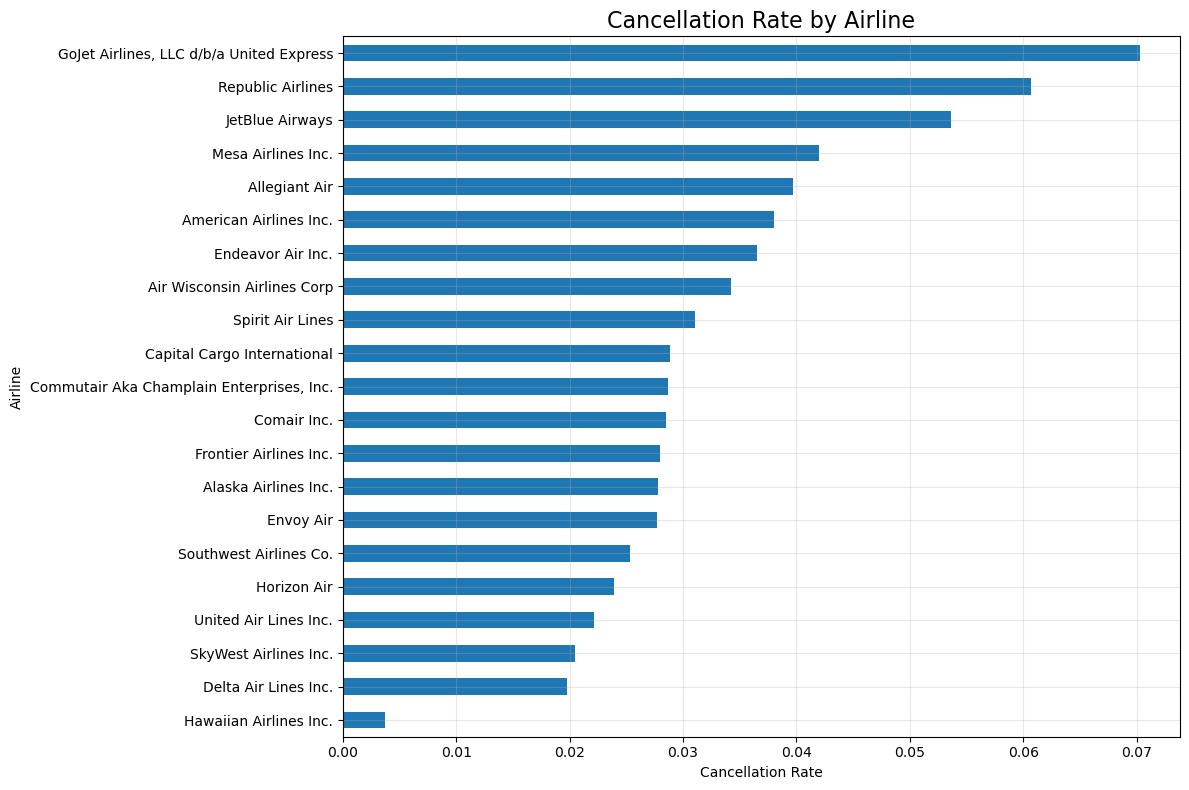

In [31]:
df["Cancelled"].value_counts()

cancel_rates= (
    df.groupby("Airline")["Cancelled"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,8))
cancel_rates.plot(kind="barh")
plt.title("Cancellation Rate by Airline", fontsize=16)
plt.xlabel("Cancellation Rate")
plt.ylabel("Airline")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/cancellation_rate_by_airline.png")
plt.show()

## Insights

Gojet Airlines and Republic Airlines have the highest cancellation rates, although still relatively low, and Hawaiian Airlines and Delta have the lowest cancellation rates, with barely any cancellations.

# Now let's buld a model to predict if a flight is delayed

In [36]:
df["Delayed"] = (df["DepDelay"] > 15).astype(int)
df["Delayed"].value_counts(normalize=True)

features = [
    "Airline",
    "DayOfWeek",
    "Month",
    "DepTimeBlk",
    "Distance"
]

X = df[features]
y = df["Delayed"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.792
              precision    recall  f1-score   support

           0       0.79      1.00      0.88     15843
           1       0.45      0.00      0.01      4157

    accuracy                           0.79     20000
   macro avg       0.62      0.50      0.45     20000
weighted avg       0.72      0.79      0.70     20000



Initial results show high overall accuracy by mainly predicted non-delayed flights however the model does not identify delayed flights so I need to adjust the model to deal with the class imbalance.

In [38]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
model.fit(X_train, y_train)
preds_balanced = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds_balanced))
print(classification_report(y_test, preds_balanced))

Accuracy: 0.59725
              precision    recall  f1-score   support

           0       0.86      0.59      0.70     15843
           1       0.29      0.64      0.40      4157

    accuracy                           0.60     20000
   macro avg       0.57      0.61      0.55     20000
weighted avg       0.74      0.60      0.64     20000



### Logistic Regression Results

The initial model achieved relatively high accuracy but failed to identify delayed flights due to class imbalance in the dataset. Applying balanced class weighting substantially improved recall for delayed flights, increasing the model's ability to better detect operational disruptions at the cost of lower overall accuracy.

These results demonstrates the importance of evaluating multiple performance metrics beyond accuracy alone. This is especially important in imbalanced operational datasets where identifying minority events is extremely important.